<a href="https://colab.research.google.com/github/anarghasunil2014-eng/My-projects-in-RNN/blob/main/Compression_of_Image_using_SVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image Shape = (557, 474)
U shape : (557, 474)
S shape : (474,)
VT shape: (474, 474)


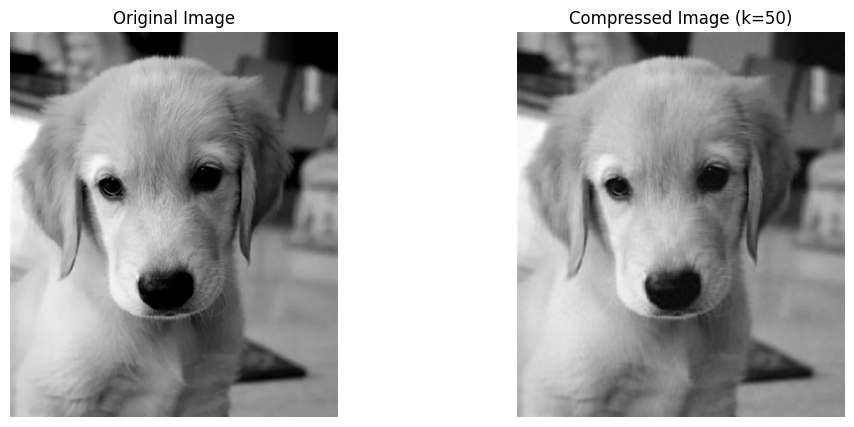

Original Storage = 264018
Compressed Storage = 51600
Compression Ratio = 5.116627906976744


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =====================================
# LOAD IMAGE AS GRAYSCALE
# =====================================

img = Image.open("dog.jpg").convert("L")

A = np.array(img, dtype=float)

print("Image Shape =", A.shape)

# =====================================
# SVD DECOMPOSITION
# A = U Σ Vᵀ
# =====================================

U, S, VT = np.linalg.svd(A, full_matrices=False)

print("U shape :", U.shape)
print("S shape :", S.shape)
print("VT shape:", VT.shape)

# =====================================
# CHOOSE RANK k
# =====================================

k = 50

# =====================================
# RECONSTRUCT USING TOP k SINGULAR VALUES
# =====================================

Uk = U[:, :k]

Sk = np.diag(S[:k])

VTk = VT[:k, :]

A_compressed = Uk @ Sk @ VTk

# =====================================
# DISPLAY IMAGES
# =====================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(A, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(A_compressed, cmap="gray")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

plt.show()

# =====================================
# COMPRESSION RATIO
# =====================================

m, n = A.shape

original_storage = m*n

compressed_storage = k*(m+n+1)

compression_ratio = original_storage/compressed_storage

print("Original Storage =", original_storage)
print("Compressed Storage =", compressed_storage)
print("Compression Ratio =", compression_ratio)